In [1]:
import numpy as np
import pandas as pd
import torch
import joblib
import os
import itertools
from tqdm.notebook import tqdm
import math
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

import torchvision
from torchvision import transforms
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from train_cmnist_models import ImageColorizerUNet

from matplotlib import pyplot as plt
from operations import Intervention

In [2]:
# ===== Cell 1: Imports, config, reproducibility =====
import os, glob, json, math, pickle, warnings
from typing import Dict, Tuple, List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.metrics import r2_score

warnings.filterwarnings("ignore", category=UserWarning)

def set_global_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
set_global_seed(42)


Device: cpu


In [3]:
# ===== Cell 2: Dataset discovery & selection =====
def discover_datasets(glob_pat: str = "data/cmnist*_clean") -> List[str]:
    return sorted(glob.glob(glob_pat))

def pick_dataset(
    data_dir: Optional[str] = None,
    data_root: str = "data/cmnist*_clean",
    select: int = 0,
    contains: Optional[str] = None,
) -> str:
    if data_dir:
        return data_dir
    ds = discover_datasets(data_root)
    if not ds:
        raise RuntimeError(f"No datasets found for glob: {data_root}")
    if contains:
        ds = [d for d in ds if contains in os.path.basename(d)]
        if not ds:
            raise RuntimeError(f"No dataset contains substring: {contains}")
    if select < 0 or select >= len(ds):
        raise RuntimeError(f"--select out of range. Found {len(ds)} datasets.")
    return ds[select]

# --- choose here if running interactively
DATA_DIR = pick_dataset(select=0)  # change index if needed
print("Using dataset:", DATA_DIR)


Using dataset: data/cmnist16_c00_clean


In [4]:
# ===== Cell 3: Load LL/HL samples & mapping =====
def load_samples(folder: str):
    dll = torch.load(os.path.join(folder, "dll_samples.pkl"))
    dhl = torch.load(os.path.join(folder, "dhl_samples.pkl"))
    omega = torch.load(os.path.join(folder, "intervention_mapping.pkl"))
    return dll, dhl, omega

Dll_samples, Dhl_samples, omega_labels = load_samples(DATA_DIR)

def get_obs_ll(Dll: Dict):
    return Dll.get("obs") or Dll.get(None) or next(iter(Dll.values()))

def get_obs_hl(Dhl: Dict):
    return Dhl.get("obs", next(iter(Dhl.values())))

print("LL keys (first 5):", list(Dll_samples.keys())[:5])
print("HL keys (first 5):", list(Dhl_samples.keys())[:5])

# quick structure peek
_ll_imgs, _ll_shapes, _ll_digits, _ll_colors = get_obs_ll(Dll_samples)
print("LL obs shapes:",
      tuple(_ll_imgs.shape), tuple(_ll_shapes.shape),
      tuple(_ll_digits.shape), tuple(_ll_colors.shape))
print("HL obs shape:", tuple(get_obs_hl(Dhl_samples).shape))


LL keys (first 5): ['obs', 'D=6', 'D=8', 'D=4', 'C=7']
HL keys (first 5): ['obs', 'D=6', 'D=8', 'D=4', 'C=7']
LL obs shapes: (1000, 3, 16, 16) (1000, 1, 16, 16) (1000,) (1000,)
HL obs shape: (1000, 21)


In [5]:
# ===== Cell 4: Load U-Net and residuals (optional, if trained) =====
def try_load_unet(folder: str):
    path = os.path.join(folder, "ll_model_unet.pth")
    if not os.path.isfile(path):
        print("No U-Net weights found. Skipping model load.")
        return None
    # import from your training module
    try:
        from cmnist_train import ImageColorizerUNet
    except Exception as e:
        print("Could not import ImageColorizerUNet from cmnist_train:", e)
        return None

    model = ImageColorizerUNet(norm_type="bn")
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    print("✓ Loaded U-Net weights:", path)
    return model

def try_load_residuals(folder: str):
    ull_path = os.path.join(folder, "U_ll_hat.pkl")
    uhl_path = os.path.join(folder, "U_hl_hat.pkl")
    U_ll = torch.load(ull_path) if os.path.isfile(ull_path) else None
    U_hl = torch.load(uhl_path) if os.path.isfile(uhl_path) else None
    if U_ll is not None: print("✓ U_ll_hat loaded:", ull_path, tuple(U_ll.shape))
    if U_hl is not None: print("✓ U_hl_hat loaded:", uhl_path, tuple(U_hl.shape))
    return U_ll, U_hl

LL_MODEL = try_load_unet(DATA_DIR)
U_LL_HAT, U_HL_HAT = try_load_residuals(DATA_DIR)


✓ Loaded U-Net weights: data/cmnist16_c00_clean/ll_model_unet.pth
✓ U_ll_hat loaded: data/cmnist16_c00_clean/U_ll_hat.pkl (1000, 3, 16, 16)
✓ U_hl_hat loaded: data/cmnist16_c00_clean/U_hl_hat.pkl (1000, 1)


In [6]:
# ===== Cell 5: Shape inference & range helpers =====
def infer_ll_dims(ll_obs_tuple) -> Tuple[int,int,int]:
    imgs, shapes, digits, colors = ll_obs_tuple
    _, C, H, W = imgs.shape
    return C, H, W

def ensure_tanh_scaled(images: torch.Tensor) -> torch.Tensor:
    # [0,1] -> [-1,1]; if already [-1,1] leave as is
    imin, imax = images.min().item(), images.max().item()
    if -1.05 <= imin and imax <= 1.05:
        return images
    if -1e-6 <= imin and imax <= 1.0 + 1e-6:
        return images * 2.0 - 1.0
    raise ValueError(f"Unexpected image range [{imin:.3f}, {imax:.3f}]")


In [7]:
# ===== Cell 6: Build (D_ll, D_hl, U_ll, U_hl) dictionaries =====
@torch.no_grad()
def predict_det_images_with_unet(model, shapes, digits, colors, batch=1024):
    preds = []
    for i in range(0, len(shapes), batch):
        s = shapes[i:i+batch].to(DEVICE)
        d = digits[i:i+batch].to(DEVICE)
        c = colors[i:i+batch].to(DEVICE)
        pred = model(s, d, c).cpu()
        preds.append(pred)
    return torch.cat(preds, dim=0)

def build_cmnist_parts(
    Dll: Dict[str, Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]],
    Dhl: Dict[str, torch.Tensor],
    ll_model = None,
    U_ll_hat: Optional[torch.Tensor] = None,
    U_hl_hat: Optional[torch.Tensor] = None,
    labels: Optional[List[str]] = None,
):
    """
    Returns:
      det_ll: dict[label] -> deterministic LL tensor  (N, 3, H, W) in [-1,1]
      det_hl: dict[label] -> deterministic HL matrix  (N, 21)
      U_ll:   dict[label] -> residual LL tensor       (N, 3, H, W) in [-1,1] (if available)
      U_hl:   dict[label] -> residual HL vector       (N, 1) (if available)
    """
    labels = labels or list(Dll.keys())
    det_ll, U_ll, det_hl, U_hl = {}, {}, {}, {}

    for lab in labels:
        imgs, shapes, digits, colors = Dll[lab]
        # LL deterministic:
        if ll_model is not None:
            ll_model.to(DEVICE).eval()
            det = predict_det_images_with_unet(ll_model, shapes, digits, colors)
            det = det  # already tanh output -> [-1,1]
        else:
            # If we have residuals saved, reconstruct det = imgs_scaled - U
            if U_ll_hat is not None and lab == "obs":
                imgs_scaled = ensure_tanh_scaled(imgs)
                det = imgs_scaled - U_ll_hat
            else:
                # fallback: use mean-colored grayscale as a crude proxy (still valid for diagnostics)
                det = ensure_tanh_scaled(imgs) * 0.0
        det_ll[lab] = det

        # LL residuals (if available)
        if U_ll_hat is not None and lab == "obs":
            U_ll[lab] = U_ll_hat
        else:
            U_ll[lab] = ensure_tanh_scaled(imgs) - det_ll[lab]

        # HL deterministic: first 20 columns are one-hots, last col is deterministic feature
        H = Dhl[lab]
        det_hl[lab] = H.clone()
        # HL residuals if available; otherwise 0-residuals by default
        if U_hl_hat is not None and lab == "obs":
            U_hl[lab] = U_hl_hat
        else:
            # residuals would be y - det; here assume last col of H is already the det, so residual ~ 0
            U_hl[lab] = torch.zeros((H.shape[0], 1), dtype=torch.float32)

    return det_ll, det_hl, U_ll, U_hl

DET_LL, DET_HL, U_LL, U_HL = build_cmnist_parts(
    Dll_samples, Dhl_samples, ll_model=LL_MODEL, U_ll_hat=U_LL_HAT, U_hl_hat=U_HL_HAT
)
print("Built parts for labels:", list(DET_LL.keys())[:5])


Built parts for labels: ['obs', 'D=6', 'D=8', 'D=4', 'C=7']


In [8]:
# ===== Cell 7: Stacking utilities (respect ω mapping) =====
def omega_identity(labels: Dict[str, str]) -> Dict[str, str]:
    # In your pipeline it's identity, keep function for generality
    return {k: v for k, v in labels.items()}

def stack_ll(det_ll: Dict[str, torch.Tensor], U_ll: Dict[str, torch.Tensor], labs: List[str]):
    Xd_list, Un_list = [], []
    for lab in labs:
        Xd_list.append(det_ll[lab])  # (N,3,H,W) [-1,1]
        Un_list.append(U_ll[lab])    # (N,3,H,W) [-1,1]
    Xd = torch.cat(Xd_list, dim=0)
    Un = torch.cat(Un_list, dim=0)
    # flatten to vectors for objective: (N, C*H*W)
    N, C, H, W = Xd.shape
    return Xd.view(N, -1), Un.view(N, -1), (C, H, W)

def stack_hl(det_hl: Dict[str, torch.Tensor], U_hl: Dict[str, torch.Tensor], labs: List[str]):
    Xd_list, Un_list = [], []
    for lab in labs:
        Xd_list.append(det_hl[lab])        # (N, 21)
        Un_list.append(U_hl[lab])          # (N, 1)
    Xd = torch.cat(Xd_list, dim=0)
    Un = torch.cat(Un_list, dim=0)
    return Xd, Un  # (N,21), (N,1)

OMEGA = omega_identity(omega_labels)
LABELS = list(OMEGA.keys())  # keep order stable
print("Labels used (ω-identity):", LABELS[:5], "... total", len(LABELS))


Labels used (ω-identity): ['obs', 'D=6', 'D=8', 'D=4', 'C=7'] ... total 10


In [9]:
# ===== Cell 8: Objectives =====
def empirical_objective_cmnist_full(
    T: torch.Tensor,          # (d_h, d_l)
    det_ll: Dict[str, torch.Tensor],
    det_hl: Dict[str, torch.Tensor],
    U_ll: Dict[str, torch.Tensor],
    U_hl: Dict[str, torch.Tensor],
    labels: List[str],
):
    """
    Sum over interventions of || T (D_l + U_l) - (D_h + U_h) ||_F^2
    Inputs stacked automatically; returns scalar loss
    """
    Xl_det, Ul, _shape = stack_ll(det_ll, U_ll, labels)     # (N, d_l)
    Xh_det, Uh = stack_hl(det_hl, U_hl, labels)             # (N, 21), (N,1)

    # select HL dims to predict: all 21 (including one-hots) or last dim only?
    # Here: full 21 to keep consistent with generalized objective
    Xl = (Xl_det + Ul).to(DEVICE)                           # (N, d_l)
    Xh = (Xh_det + torch.cat([torch.zeros_like(Xh_det[:, :20]), Uh], dim=1)).to(DEVICE)  # add noise only on last dim
    pred = Xl @ T.t()                                       # (N, 21)
    loss = F.mse_loss(pred, Xh)
    return loss

def barycentric_objective_cmnist(
    T: torch.Tensor,
    det_ll: Dict[str, torch.Tensor],
    det_hl: Dict[str, torch.Tensor],
    labels: List[str],
):
    """
    BARYCA-style: use deterministic parts only (affine mixers already embedded).
    """
    Xl_det, _Ul, _shape = stack_ll(det_ll, {k: torch.zeros_like(det_ll[k]) for k in labels}, labels)
    Xh_det, _Uh = stack_hl(det_hl, {k: torch.zeros((det_hl[k].shape[0], 1)) for k in labels}, labels)

    Xl = Xl_det.to(DEVICE)   # (N, d_l)
    Xh = Xh_det.to(DEVICE)   # (N, 21)
    pred = Xl @ T.t()
    return F.mse_loss(pred, Xh)


In [10]:
# ===== Cell 9: Adversary projection (Frobenius balls) =====
def project_onto_frobenius_ball(X: torch.Tensor, radius: float) -> torch.Tensor:
    with torch.no_grad():
        nrm = X.norm(p='fro')
        if nrm > radius:
            X.mul_(radius / (nrm + 1e-12))
    return X

def inner_max_step(
    T: torch.Tensor,
    Theta: torch.Tensor,   # (N, d_l)
    Phi: torch.Tensor,     # (N, 21)
    radius_l: float,
    radius_h: float,
    step: float = 1.0,
):
    """
    Simple ascent step on Θ, Φ for the empirical objective's gradient proxy:
      grad_Theta ≈ (Xl_det + Θ) @ T^T - (Xh_det + Φ) back-projected
    Here we perform a generic gradient ascent on Θ, Φ w.r.t. squared error:
      ||(Xl_det + Θ) T^T - (Xh_det + Φ)||^2
    NOTE: This is a practical helper; the exact closed-form inner max was derived in your theorem.
    """
    Theta.add_(step * Theta.grad)  # ascent
    Phi.add_(step * Phi.grad)
    Theta.grad = None
    Phi.grad = None
    project_onto_frobenius_ball(Theta, radius_l)
    project_onto_frobenius_ball(Phi, radius_h)


In [11]:
# ===== Cell 10: ERICA/DiRoCA & baselines =====
def run_diroca(
    det_ll, det_hl, U_ll, U_hl, labels,
    iters=200, lr_T=1e-2, lr_inner=1e-1,
    steps_inner=3, radius_l=1.0, radius_h=1.0, verbose=True
):
    # Prepare stacked data
    Xl_det, Ul, _shape = stack_ll(det_ll, U_ll, labels)  # (N, d_l)
    Xh_det, Uh = stack_hl(det_hl, U_hl, labels)          # (N, 21), (N,1)
    N, d_l = Xl_det.shape
    d_h = Xh_det.shape[1]

    # Only add noise on last HL dim (Image_)
    Xh_noise = torch.cat([torch.zeros_like(Xh_det[:, :20]), Uh], dim=1)

    Xl_det = Xl_det.to(DEVICE)
    Ul = Ul.to(DEVICE)
    Xh_det = Xh_det.to(DEVICE)
    Xh_noise = Xh_noise.to(DEVICE)

    # params
    T = torch.zeros((d_h, d_l), device=DEVICE, requires_grad=True)
    nn.init.xavier_uniform_(T)

    # adversaries
    Theta = torch.zeros_like(Xl_det, device=DEVICE, requires_grad=True)
    Phi   = torch.zeros_like(Xh_det, device=DEVICE, requires_grad=True)

    optT = torch.optim.Adam([T], lr=lr_T)

    history = []
    for it in range(1, iters+1):
        # --- minimize over T for fixed adversaries (few steps)
        optT.zero_grad()
        pred = (Xl_det + Ul + Theta) @ T.t()
        target = Xh_det + Xh_noise + Phi
        loss = F.mse_loss(pred, target)
        loss.backward()
        optT.step()

        # --- maximize over (Theta, Phi) (inner)
        for _ in range(steps_inner):
            # recompute graphs for grads w.r.t adversaries
            Theta.grad = None; Phi.grad = None
            pred = (Xl_det + Ul + Theta) @ T.t()
            target = Xh_det + Xh_noise + Phi
            inner = F.mse_loss(pred, target)
            inner.backward()
            inner_max_step(T, Theta, Phi, radius_l, radius_h, step=lr_inner)

        if verbose and (it % 10 == 0 or it == 1):
            history.append(float(loss.item()))
            print(f"[DiRoCA] it={it:04d} loss={loss.item():.6f}")

    return T.detach().cpu(), history

def run_gradca(det_ll, det_hl, labels, iters=200, lr_T=1e-2, verbose=True):
    Xl_det, _Ul, _shape = stack_ll(det_ll, {k: torch.zeros_like(det_ll[k]) for k in labels}, labels)
    Xh_det, _Uh = stack_hl(det_hl, {k: torch.zeros((det_hl[k].shape[0], 1)) for k in labels}, labels)
    N, d_l = Xl_det.shape
    d_h = Xh_det.shape[1]

    Xl_det = Xl_det.to(DEVICE)
    Xh_det = Xh_det.to(DEVICE)

    T = torch.zeros((d_h, d_l), device=DEVICE, requires_grad=True)
    nn.init.xavier_uniform_(T)
    optT = torch.optim.Adam([T], lr=lr_T)

    history = []
    for it in range(1, iters+1):
        optT.zero_grad()
        pred = Xl_det @ T.t()
        loss = F.mse_loss(pred, Xh_det)
        loss.backward()
        optT.step()
        if verbose and (it % 10 == 0 or it == 1):
            history.append(float(loss.item()))
            print(f"[GradCA] it={it:04d} loss={loss.item():.6f}")
    return T.detach().cpu(), history

def run_baryca(det_ll, det_hl, labels):
    # closed-form least squares on deterministic stacks
    Xl_det, _Ul, _shape = stack_ll(det_ll, {k: torch.zeros_like(det_ll[k]) for k in labels}, labels)
    Xh_det, _Uh = stack_hl(det_hl, {k: torch.zeros((det_hl[k].shape[0], 1)) for k in labels}, labels)
    # T = Xh * Xl^+
    Xl_pinv = torch.linalg.pinv(Xl_det)
    T = (Xh_det.t() @ Xl_pinv.t()).t()  # careful with shapes; produce (d_l, d_h) then transpose
    T = T.t().contiguous()
    return T


In [12]:
# ===== Cell 11: Empirical error & evaluation =====
def empirical_error_flat(
    T: torch.Tensor,
    det_ll: Dict[str, torch.Tensor],
    det_hl: Dict[str, torch.Tensor],
    U_ll: Dict[str, torch.Tensor],
    U_hl: Dict[str, torch.Tensor],
    labels: List[str],
) -> float:
    Xl_det, Ul, _shape = stack_ll(det_ll, U_ll, labels)
    Xh_det, Uh = stack_hl(det_hl, U_hl, labels)
    Xl = (Xl_det + Ul).to(DEVICE)
    Xh = (Xh_det + torch.cat([torch.zeros_like(Xh_det[:, :20]), Uh], dim=1)).to(DEVICE)
    pred = Xl @ T.to(DEVICE).t()
    return float(F.mse_loss(pred, Xh).item())

def evaluate_methods(det_ll, det_hl, U_ll, U_hl, labels):
    print("== Evaluate: GradCA, BARYCA, DiRoCA ==")
    T_grad, _ = run_gradca(det_ll, det_hl, labels, verbose=False)
    T_bary = run_baryca(det_ll, det_hl, labels)
    T_diro, _ = run_diroca(det_ll, det_hl, U_ll, U_hl, labels, verbose=False)

    e_grad = empirical_error_flat(T_grad, det_ll, det_hl, U_ll, U_hl, labels)
    e_bary = empirical_error_flat(T_bary, det_ll, det_hl, U_ll, U_hl, labels)
    e_diro = empirical_error_flat(T_diro, det_ll, det_hl, U_ll, U_hl, labels)
    print(f"GradCA error: {e_grad:.6f}")
    print(f"BARYCA error: {e_bary:.6f}")
    print(f"DiRoCA error: {e_diro:.6f}")
    return {"GradCA": (T_grad, e_grad), "BARYCA": (T_bary, e_bary), "DiRoCA": (T_diro, e_diro)}

# (Optional quick run)
# results = evaluate_methods(DET_LL, DET_HL, U_LL, U_HL, LABELS)


In [13]:
# ===== Cell 12: Abs-LiNGAM (single wrapper) =====
def run_abs_lingam_cmnist(
    det_ll: Dict[str, torch.Tensor],
    det_hl: Dict[str, torch.Tensor],
    labels: List[str]
):
    """
    Build flattened LL/HL matrices over all interventions and apply Abs-LiNGAM
    to learn a linear mapping. Returns T of shape (21, d_l).
    """
    try:
        from lingam import DirectLiNGAM
    except Exception as e:
        print("Abs-LiNGAM not available:", e)
        return None

    Xl_det, _Ul, _shape = stack_ll(det_ll, {k: torch.zeros_like(det_ll[k]) for k in labels}, labels)  # (N, d_l)
    Xh_det, _Uh = stack_hl(det_hl, {k: torch.zeros((det_hl[k].shape[0], 1)) for k in labels}, labels)  # (N, 21)

    # We want a linear mapping that best aligns Xl -> Xh. One approach:
    # Learn a DAG over concatenated [Xl | Xh] and regress Xh on Xl.
    X = torch.cat([Xl_det, Xh_det], dim=1).numpy()
    model = DirectLiNGAM()
    model.fit(X)
    # simple least squares from Xl_det to Xh_det:
    T = torch.linalg.lstsq(Xl_det, Xh_det).solution.t().contiguous()  # (21, d_l)
    return T


In [14]:
# ===== Cell 13: Huber-style contamination =====
def apply_huber_contamination_cmnist(
    det_ll, det_hl, U_ll, U_hl, labels,
    alpha=0.1, sigma=0.05, seed=0
):
    """
    Contaminate a fraction alpha of samples by adding Gaussian noise with std=sigma
    to the noise parts (LL pixels and HL Image_).
    """
    rng = np.random.default_rng(seed)

    # LL
    Xl_det, Ul, _shape = stack_ll(det_ll, U_ll, labels)  # (N, d_l)
    Xh_det, Uh = stack_hl(det_hl, U_hl, labels)          # (N, 21), (N,1)
    N = Xl_det.shape[0]
    idx = rng.choice(N, size=int(alpha*N), replace=False)

    Ul_cont = Ul.clone()
    Uh_cont = Uh.clone()
    Ul_cont[idx] += torch.randn_like(Ul_cont[idx]) * sigma
    Uh_cont[idx] += torch.randn_like(Uh_cont[idx]) * sigma

    # rebuild per-label dicts with contaminated noise (keep deterministics)
    sizes = [det_ll[lab].shape[0] for lab in labels]
    cuts = np.cumsum([0] + sizes)

    U_ll_new, U_hl_new = {}, {}
    for i, lab in enumerate(labels):
        s, e = cuts[i], cuts[i+1]
        C, H, W = det_ll[lab].shape[1:]
        U_ll_new[lab] = Ul_cont[s:e].view(-1, C, H, W)
        U_hl_new[lab] = Uh_cont[s:e]
    return det_ll, det_hl, U_ll_new, U_hl_new


In [15]:
# ===== Cell 14: Minimal tracker =====
class Tracker:
    def __init__(self): self.rows = []
    def log(self, **kw): self.rows.append({k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in kw.items()})
    def to_list(self): return self.rows
    def plot(self, key="loss"):
        ys = [r[key] for r in self.rows if key in r]
        if not ys: 
            print(f"No '{key}' logged."); return
        plt.figure(figsize=(5,3)); plt.plot(ys); plt.title(key); plt.grid(True, ls='--', alpha=0.4); plt.show()


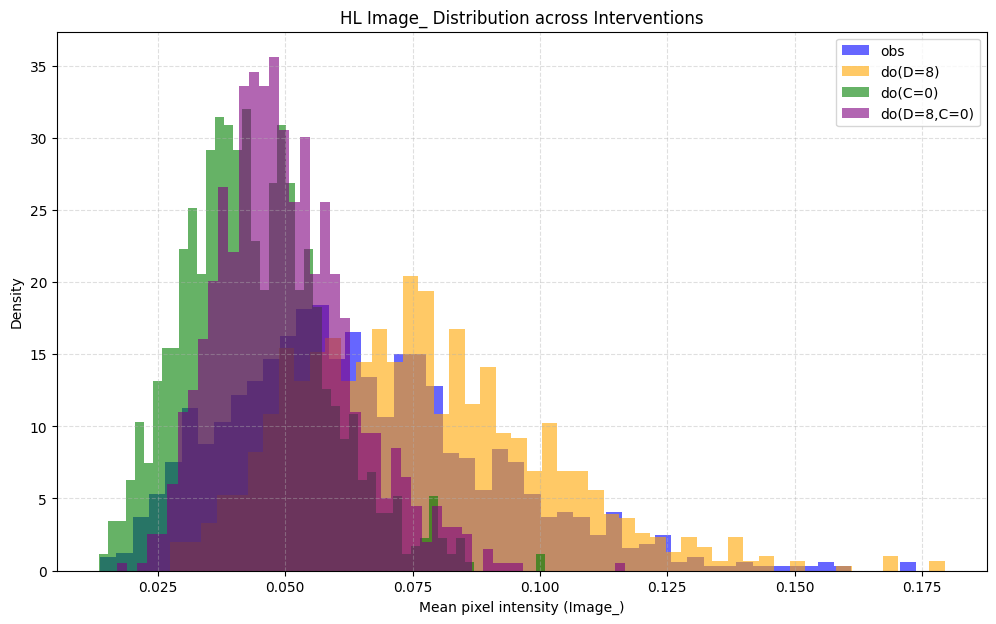

In [16]:
# ===== Cell 15: HL 'Image_' distribution diagnostics =====
def hl_lastcol(arr: torch.Tensor) -> np.ndarray:
    return arr[:, -1].detach().cpu().numpy()

def pick_keys_for_quartet(Dhl: Dict[str, torch.Tensor]):
    keys = list(Dhl.keys())
    obs = "obs" if "obs" in keys else keys[0]
    dkey = "D=8" if "D=8" in keys else next((k for k in keys if isinstance(k, str) and k.startswith("D=")), keys[1])
    ckey = "C=0" if "C=0" in keys else next((k for k in keys if isinstance(k, str) and k.startswith("C=")), keys[2])
    combo = "D=8,C=0" if "D=8,C=0" in keys else next((k for k in keys if isinstance(k, str) and "," in k), None)
    return obs, dkey, ckey, combo

def plot_hl_image_distributions(Dhl: Dict[str, torch.Tensor]):
    obs, dkey, ckey, combo = pick_keys_for_quartet(Dhl)
    vals = {
        "obs": hl_lastcol(Dhl[obs]),
        f"do({dkey})": hl_lastcol(Dhl[dkey]) if dkey in Dhl else None,
        f"do({ckey})": hl_lastcol(Dhl[ckey]) if ckey in Dhl else None,
    }
    if combo and combo in Dhl:
        vals[f"do({combo})"] = hl_lastcol(Dhl[combo])

    plt.figure(figsize=(12, 7))
    colors = ['blue', 'orange', 'green', 'purple']
    for i, (name, arr) in enumerate(vals.items()):
        if arr is None: continue
        plt.hist(arr, bins=50, density=True, alpha=0.6, label=name, color=colors[i % len(colors)])
    plt.title("HL Image_ Distribution across Interventions")
    plt.xlabel("Mean pixel intensity (Image_)"); plt.ylabel("Density")
    plt.grid(ls='--', alpha=0.4); plt.legend(); plt.show()

plot_hl_image_distributions(Dhl_samples)


Background τ=0.02242; vlim=0.18228


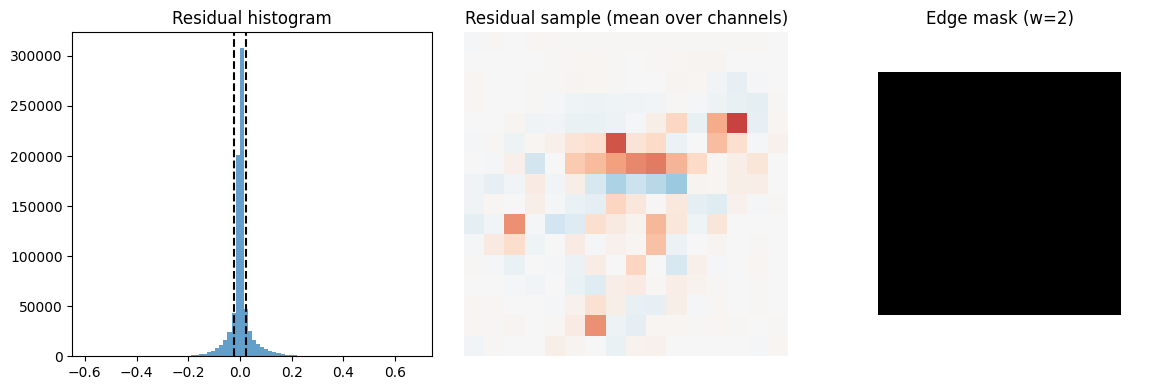

In [17]:
# ===== Cell 16: U_ll background & edge analysis (compact) =====
def analyze_U_ll_background(U_ll: torch.Tensor, sample_idx: int = 0):
    assert U_ll.dim() == 4, "Expected (N,C,H,W)"
    N, C, H, W = U_ll.shape
    vals = U_ll.detach().cpu().numpy().reshape(-1)
    vlim = max(np.percentile(np.abs(vals), 99), 1e-3)

    # adaptive bg threshold
    tau = float(0.5 * U_ll.std().item())
    print(f"Background τ={tau:.5f}; vlim={vlim:.5f}")

    # masks for a sample
    img = U_ll[sample_idx].detach().cpu()
    edge_w = max(1, int(round(min(H, W) * 0.125)))
    edge_mask = torch.zeros((H, W), dtype=torch.bool)
    edge_mask[:edge_w, :] = True; edge_mask[-edge_w:, :] = True
    edge_mask[:, :edge_w] = True; edge_mask[:, -edge_w:] = True
    center_mask = ~edge_mask

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].hist(vals, bins=80, alpha=0.7)
    axes[0].axvline(+tau, color='k', ls='--'); axes[0].axvline(-tau, color='k', ls='--')
    axes[0].set_title("Residual histogram")

    if C == 1:
        axes[1].imshow(img[0], cmap='RdBu_r', vmin=-vlim, vmax=+vlim)
    else:
        axes[1].imshow(img.mean(0), cmap='RdBu_r', vmin=-vlim, vmax=+vlim)
    axes[1].set_title("Residual sample (mean over channels)"); axes[1].axis('off')

    axes[2].imshow(edge_mask, cmap='gray'); axes[2].set_title(f"Edge mask (w={edge_w})"); axes[2].axis('off')
    plt.tight_layout(); plt.show()

# if available:
if U_LL_HAT is not None:
    analyze_U_ll_background(U_LL_HAT, sample_idx=0)
